In [18]:
import matplotlib.pyplot as plt

SA_RC = {
    # --- Figure ---
    'figure.figsize': (4, 3),
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'figure.autolayout': True,

    # --- Axes ---
    'axes.facecolor': 'white',
    'axes.edgecolor': '#444444',
    'axes.linewidth': 0.8,
    'axes.spines.top': True,  # both spines visible (commented-out removal kept)
    'axes.spines.right': True,
    'axes.labelsize': 12,
    'axes.labelcolor': 'black',
    'axes.titlelocation': 'center',

    # --- Grid ---
    'axes.grid': False,  # no grid in source plot

    # --- Ticks ---
    'xtick.labelsize': 12,
    'xtick.color': 'black',
    'xtick.direction': 'out',
    'ytick.labelsize': 10,
    'ytick.color': 'black',
    'ytick.direction': 'out',

    # --- Font ---
    'font.family': 'sans-serif',
    'font.serif': ['computer modern roman'],
    'font.sans-serif': ['Helvetica Neue LT Pro'],
    'font.size': 10,
    'text.color': 'black',
    'font.weight': '300', 'axes.labelweight': '500',

    # --- Patches (bars, legend swatches) ---
    'patch.edgecolor': 'black',
    'patch.linewidth': 0.7,
    'patch.force_edgecolor': True,

    # --- Legend ---
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
    'legend.framealpha': 0.0,  # transparent legend box
    'legend.edgecolor': '#444444',

    # --- Lines ---
    'lines.linewidth': 0.7,

    # --- Saving ---
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
}
plt.rcParams.update(SA_RC)
dir_paper_figure = r"D:\pykan\github\workflows\Hyein\figures_for_paper"

In [19]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# Shared configuration
# ============================================================
ROOT_DIR           = r"D:\pykan\github\workflows\Hyein"
MODEL_DIR_TEMPLATE = os.path.join(ROOT_DIR, "material_kan_models", "{name_data}")

# Method label -> (filename pattern, column name in that csv).
SOURCES = {
    'S1':   ("{name_data}_sobol_indices_salib.csv",       'S1'),
    'SHAP': ("{name_data}_shap_importance.csv",           'Mean_Abs_SHAP'),
    'KAN':  ("{name_data}_global_attribution_scores.csv", 'Global_Attribution_Score'),
}

# Analytic function datasets
ANALYTIC_DIR_TEMPLATE = os.path.join(ROOT_DIR, "analytical_results", "{name_data}")
ANALYTIC_SOURCES = {
    'S1':   ("sobol_indices_global.csv",                                                           'First_Order (S1)'),
    'SHAP': ("shap_mean_abs_global.csv",                                                           'Mean_Abs_SHAP'),
    'KAN':  (os.path.join("kan_models", "{name_data}_global_attribution_scores_saltelli.csv"),     'Global_Attribution_Score'),
}


# ============================================================
# Data loading
# ============================================================
def load_attribution_scores(name_data, sources=SOURCES, model_dir_template=MODEL_DIR_TEMPLATE):
    """Return a (features x methods) DataFrame, normalised so each column sums to 1
    and sorted by the KAN score (descending)."""
    model_dir = model_dir_template.format(name_data=name_data)

    def _load_series(method, fname_pat, col):
        fname = fname_pat.format(name_data=name_data)
        return (pd.read_csv(os.path.join(model_dir, fname))
                  .set_index('Feature')[col]
                  .rename(method))

    df = pd.concat(
        [_load_series(method, fname_pat, col)
         for method, (fname_pat, col) in sources.items()],
        axis=1,
    )

    df.index = (df.index
                .str.replace(r'\s*\(.*?\)', '', regex=True)
                .str.replace(r'\s*\[.*?\]', '', regex=True))

    return (df.sort_values('KAN', ascending=False)
              .pipe(lambda d: d / d.sum()))


def load_kan_metadata(name_data, n_features, model_dir):
    """Return n_layers, num_params, R2 from the KAN metrics JSON.
    Searches model_dir first, then model_dir/kan_models/."""
    for search_dir in [model_dir, os.path.join(model_dir, "kan_models")]:
        json_path = os.path.join(search_dir, f"{name_data}_kan_metrics.json")
        if os.path.exists(json_path):
            with open(json_path) as f:
                data = json.load(f)
            p = data.get('best_params', {})
            grid, k = p.get('grid', 10), p.get('k', 3)
            return {
                'n_layers':   p.get('n_layers', 1),
                'num_params': n_features * 1 * (grid + k + 1),
                'R2':         data.get('test_r2'),
            }
    return {'n_layers': None, 'num_params': None, 'R2': None}


# ============================================================
# Core: bar plot (handles BOTH standalone and subplot use)
# ============================================================
def plot_attribution_bars(df_methods, name_data, ax=None, save=True):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots()

    num_feat = len(df_methods)
    colors   = [plt.get_cmap('RdYlBu')(x) for x in np.linspace(0.1, 0.9, num_feat)]

    df_methods.T.plot(kind='bar', rot=0, color=colors, alpha=0.9, ax=ax)
    ax.set_xlabel('Method')
    ax.set_ylabel('Global Attribution Score')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

    legend_fontsize = None if standalone else 8
    legend_ncol = 2 if len(df_methods) < 9 else 3
    ax.legend(ncol=legend_ncol, fontsize=legend_fontsize,
              title=name_data, title_fontsize=legend_fontsize)
    if standalone and save:
        model_dir = MODEL_DIR_TEMPLATE.format(name_data=name_data)
        for out_dir, base in [(model_dir,        f"{name_data}_VS_conventional"),
                              (dir_paper_figure, f"VS_conventionals_{name_data}")]:
            plt.savefig(os.path.join(out_dir, f"{base}.png"))
            plt.savefig(os.path.join(out_dir, f"{base}.svg"), format='svg')
    if standalone:
        plt.show()

    return ax

# ============================================================
# Core: rank-agreement metrics
# ============================================================
def compute_rank_metrics(df_methods, name_data=None, eps=0.001, ref='KAN',
                         verbose=True, save=False):
    mask_drop = (df_methods < eps).all(axis=1)
    n_dropped = int(mask_drop.sum())
    df_filt   = df_methods.loc[~mask_drop] if n_dropped else df_methods

    if verbose:
        if n_dropped:
            print(f"Dropping {n_dropped} feature(s) below eps={eps} in all methods:")
            print(df_methods[mask_drop].round(4).to_string())
        else:
            print(f"All features are above eps={eps} in at least one method.")

    methods = df_filt.columns.tolist()
    rho = pd.DataFrame(
        [[spearmanr(df_filt[m1], df_filt[m2])[0] for m2 in methods] for m1 in methods],
        index=methods, columns=methods,
    )

    baselines = [m for m in methods if m != ref]
    record = {
        'Dataset':    name_data,
        'n_features': len(df_methods),
        'n_dropped':  n_dropped,
    }
    for m in baselines:
        record[f'rho_{ref}_vs_{m}'] = rho.loc[ref, m]

    if verbose:
        summary_df = pd.DataFrame({
            'rho': pd.Series({m: record[f'rho_{ref}_vs_{m}'] for m in baselines}),
        }).round(3)
        print(f"\n{ref} vs. baselines (eps={eps}, n_features kept = {len(df_filt)}):")
        print(summary_df.to_string())

    if save and name_data is not None:
        model_dir = MODEL_DIR_TEMPLATE.format(name_data=name_data)
        rho.to_csv(os.path.join(model_dir, f"{name_data}_spearman_corr.csv"))

    return rho, record


# ============================================================
# Orchestrators
# ============================================================
def analyze_dataset(name_data, eps=0.001, save=True):
    """Single-dataset: standalone bar plot + verbose metrics summary."""
    print(f"=== {name_data} ===")
    df_methods = load_attribution_scores(name_data)
    plot_attribution_bars(df_methods, name_data, save=save)
    compute_rank_metrics(df_methods, name_data, eps=eps, verbose=True, save=save)
    return df_methods


def analyze_dataset_list(data_list, eps=0.001, ref='KAN',
                         ncols=3, save=True, combined_name='all_datasets',
                         title_map=None, model_dir_template=MODEL_DIR_TEMPLATE,
                         sources=SOURCES):
    """Multi-dataset: shared subplot figure + combined metrics CSV."""
    n     = len(data_list)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4.5 * ncols, 3.5 * nrows),
                             constrained_layout=True)
    axes_flat = np.atleast_1d(axes).flatten()

    records = []
    for ax, name_data in zip(axes_flat, data_list):
        print(f"=== {name_data} ===")
        display_title = (title_map or {}).get(name_data, name_data)
        df_methods = load_attribution_scores(name_data, sources=sources,
                                             model_dir_template=model_dir_template)
        plot_attribution_bars(df_methods, display_title, ax=ax, save=False)
        _, record = compute_rank_metrics(df_methods, name_data, eps=eps,
                                         ref=ref, verbose=False, save=False)

        model_dir = model_dir_template.format(name_data=name_data)
        metadata = load_kan_metadata(name_data, n_features=len(df_methods), model_dir=model_dir)
        record.update(metadata)

        # Top-ranked feature by Sobol index; record its score from all three methods
        top_feat = df_methods['S1'].idxmax()
        record['top_feature']   = top_feat
        record['top_feat_S1']   = df_methods.loc[top_feat, 'S1']
        record['top_feat_SHAP'] = df_methods.loc[top_feat, 'SHAP']
        record['top_feat_KAN']  = df_methods.loc[top_feat, 'KAN']

        records.append(record)

    for ax in axes_flat[n:]:
        ax.axis('off')

    if save:
        plt.savefig(os.path.join(dir_paper_figure, f"{combined_name}.png"))
        plt.savefig(os.path.join(dir_paper_figure, f"{combined_name}.svg"), format='svg')
        plt.savefig(os.path.join(dir_paper_figure, f"{combined_name}.eps"), format='eps')
    plt.show()

    df_metrics = pd.DataFrame(records)

    # Move rho columns to the far right
    rho_cols   = [c for c in df_metrics.columns if c.startswith('rho_')]
    other_cols = [c for c in df_metrics.columns if not c.startswith('rho_')]
    df_metrics = df_metrics[other_cols + rho_cols]

    print(f"\n=== Combined metrics across {n} datasets (eps={eps}) ===")
    print(df_metrics.to_string(index=False, float_format='{:.3f}'.format))

    if save:
        csv_path = os.path.join(dir_paper_figure, f"{combined_name}_metrics.csv")
        df_metrics.to_csv(csv_path, index=False)
        print(f"\nMetrics saved to: {csv_path}")

    return df_metrics

## Analytic Function

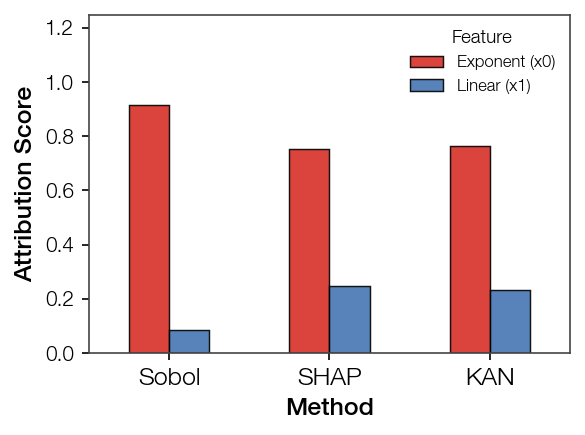

In [20]:
import pandas as pd
import os
import numpy as np

fun_analytic = 'exponential'

dir_analytic = r"D:\pykan\github\workflows\Hyein\analytical_results"
file_sobol = os.path.join(dir_analytic, fun_analytic, "sobol_indices_global.csv")
file_shap = os.path.join(dir_analytic, fun_analytic, "shap_mean_abs_global.csv")
file_kan = os.path.join(dir_analytic, fun_analytic, "kan_models", f"{fun_analytic}_global_attribution_scores_saltelli.csv")

df_sobol = pd.read_csv(file_sobol)
feat_names = df_sobol['Feature'].tolist()
s_sobol = df_sobol['First_Order (S1)'].tolist()

df_shap = pd.read_csv(file_shap)
s_shap = df_shap['Mean_Abs_SHAP'].tolist()

df_KAN = pd.read_csv(file_kan)
s_kan = df_KAN['Global_Attribution_Score'].tolist()

s_ALL = {
    'Feature': feat_names,
    'Sobol': s_sobol,
    'SHAP': s_shap,
    'KAN': s_kan
}
df_all = pd.DataFrame(s_ALL)

numeric_cols = ['Sobol', 'SHAP', 'KAN']
df_all[numeric_cols] = df_all[numeric_cols] / df_all[numeric_cols].sum()
# 2. Reshape the data for plotting
# Set 'Feature' as the index and select the method columns
df_methods = df_all.set_index('Feature')[numeric_cols]

# Transpose the DataFrame so Methods become the rows (x-axis)
# and Features become the columns (individual bars per group)
df_transposed = df_methods.T

# 3. Create the plot using pandas built-in wrapper
# This automatically handles dynamic counts of features
num_feat = len(feat_names)
cmap = plt.get_cmap('RdYlBu')
custom_colors = [cmap(x) for x in np.linspace(0.1, 0.9, num_feat)]
ax = df_transposed.plot(kind='bar', rot=0, color=custom_colors, alpha=0.9)
y_min, y_max = ax.get_ylim()
ax.set_ylim([0, y_max*1.3])

# 4. Customize axes and labels
ax.set_xlabel('Method')
ax.set_ylabel('Attribution Score')
ax.legend(title='Feature')

# Adjust layout and display
plt.savefig(os.path.join(dir_analytic, fun_analytic, "VS_conventional.png"))
plt.savefig(os.path.join(dir_analytic, fun_analytic, "VS_conventional.svg"), format='svg')
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventional_{fun_analytic}.png"))
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventional_{fun_analytic}.svg"), format='svg')
plt.show()

=== exponential ===
=== logarithm ===
=== log2 ===
=== rosenbrock ===


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


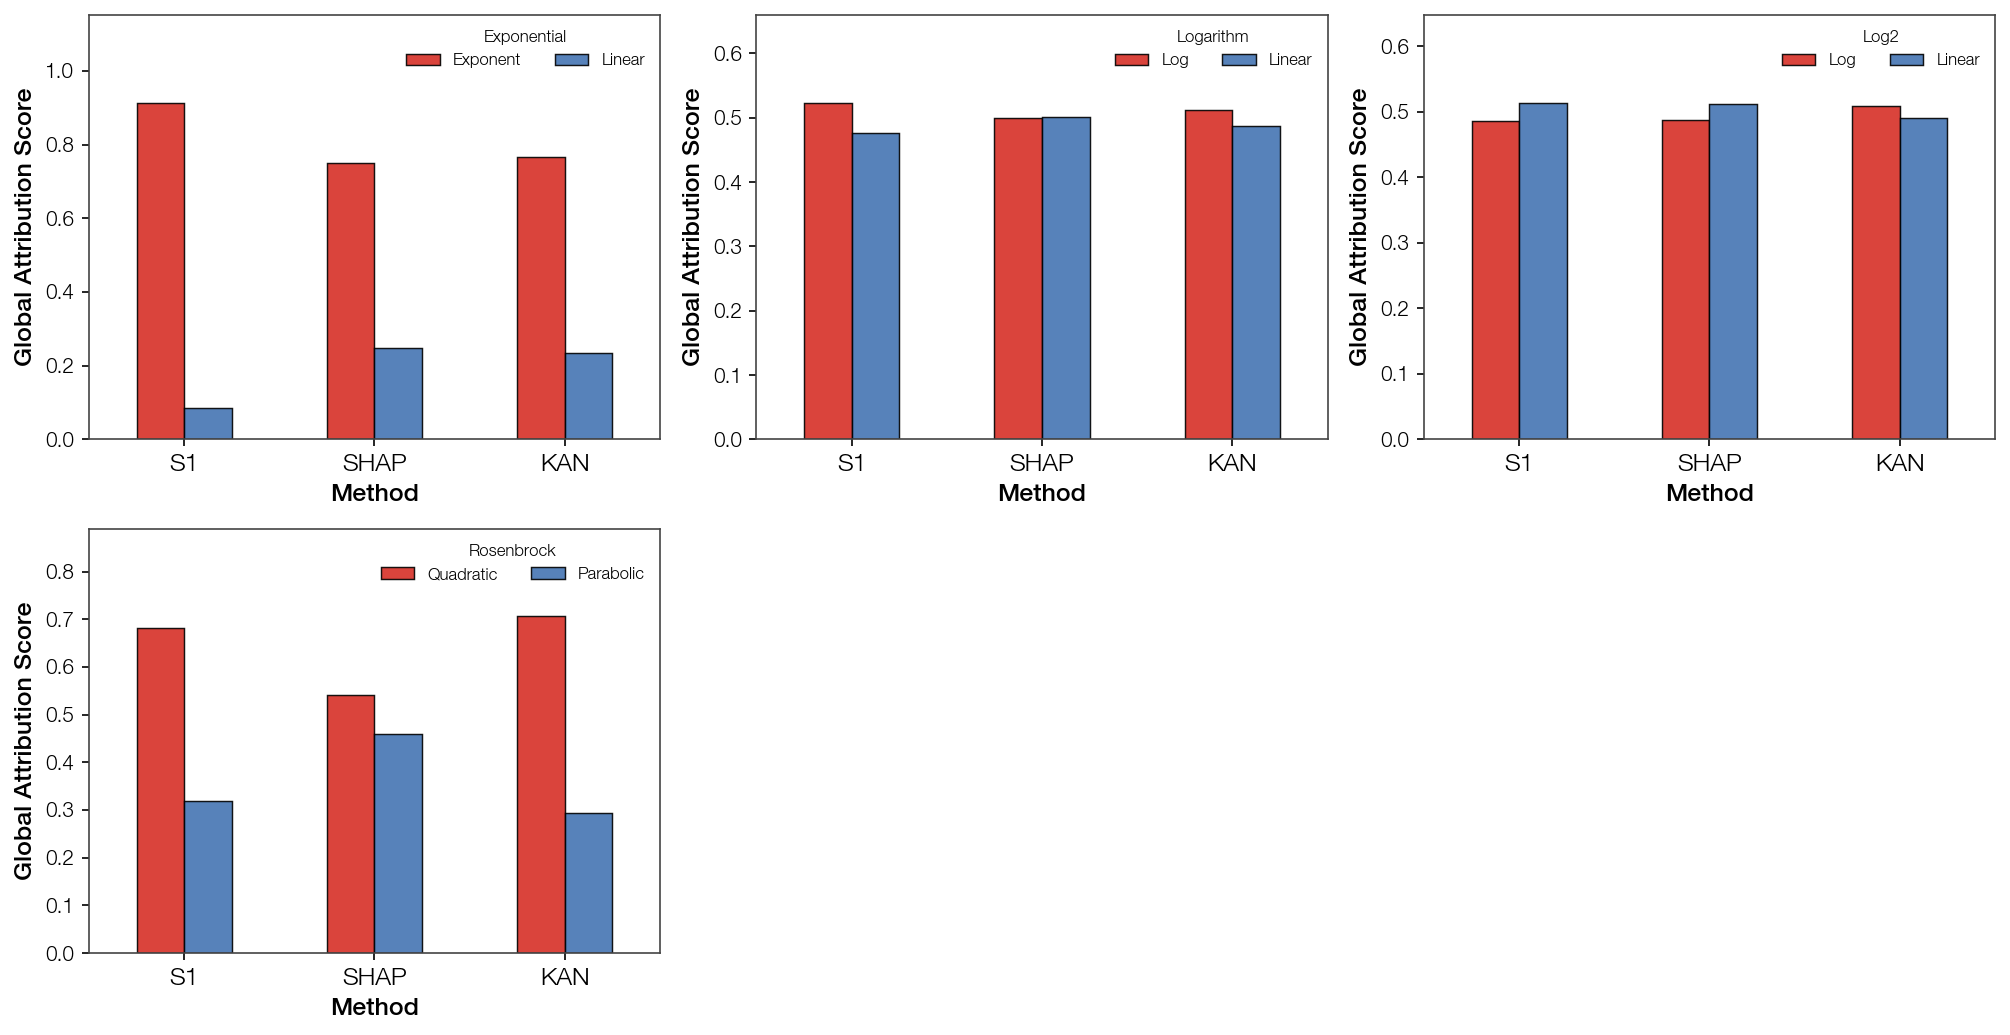


=== Combined metrics across 4 datasets (eps=0.001) ===
    Dataset  n_features  n_dropped  n_layers  num_params    R2 top_feature  top_feat_S1  top_feat_SHAP  top_feat_KAN  rho_KAN_vs_S1  rho_KAN_vs_SHAP
exponential           2          0         1          28 1.000    Exponent        0.914          0.751         0.766          1.000            1.000
  logarithm           2          0         1          28 1.000         Log        0.524          0.499         0.512          1.000           -1.000
       log2           2          0         2          28 1.000      Linear        0.514          0.513         0.491         -1.000           -1.000
 rosenbrock           2          0         2          28 0.911   Quadratic        0.681          0.541         0.706          1.000            1.000

Metrics saved to: D:\pykan\github\workflows\Hyein\figures_for_paper\VS_conventionals_Analytic_metrics.csv


In [27]:
analytic_fun_list = ['exponential', 'logarithm', 'log2', 'rosenbrock']
title_map_analytic = {
    'exponential': 'Exponential',
    'logarithm':   'Logarithm',
    'log2':        'Log2',
    'rosenbrock':  'Rosenbrock'
}
df_metrics_analytic = analyze_dataset_list(
    analytic_fun_list,
    eps=0.001,
    title_map=title_map_analytic,
    model_dir_template=ANALYTIC_DIR_TEMPLATE,
    sources=ANALYTIC_SOURCES,
    combined_name='VS_conventionals_Analytic',
)

## Pre-defined Dataset

=== ITHH4500 ===


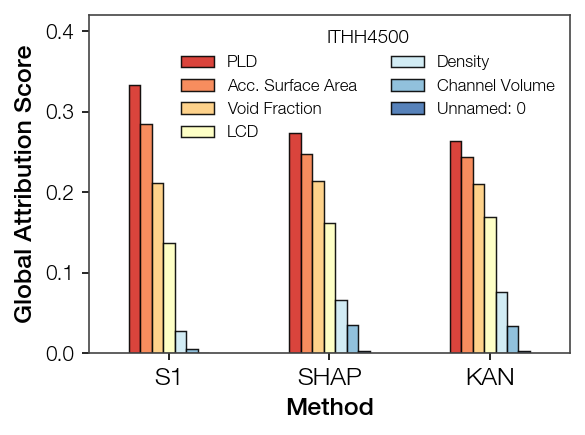

All features are above eps=0.001 in at least one method.

KAN vs. baselines (eps=0.001, n_features kept = 7):
      rho
S1    1.0
SHAP  1.0


In [22]:
df = analyze_dataset('ITHH4500')

=== AgNP ===
=== CO2AR4500 ===
=== CO2AH4500 ===
=== CO2RRLCA ===
=== CO2RRNPV ===
=== CO2HPx10 ===


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


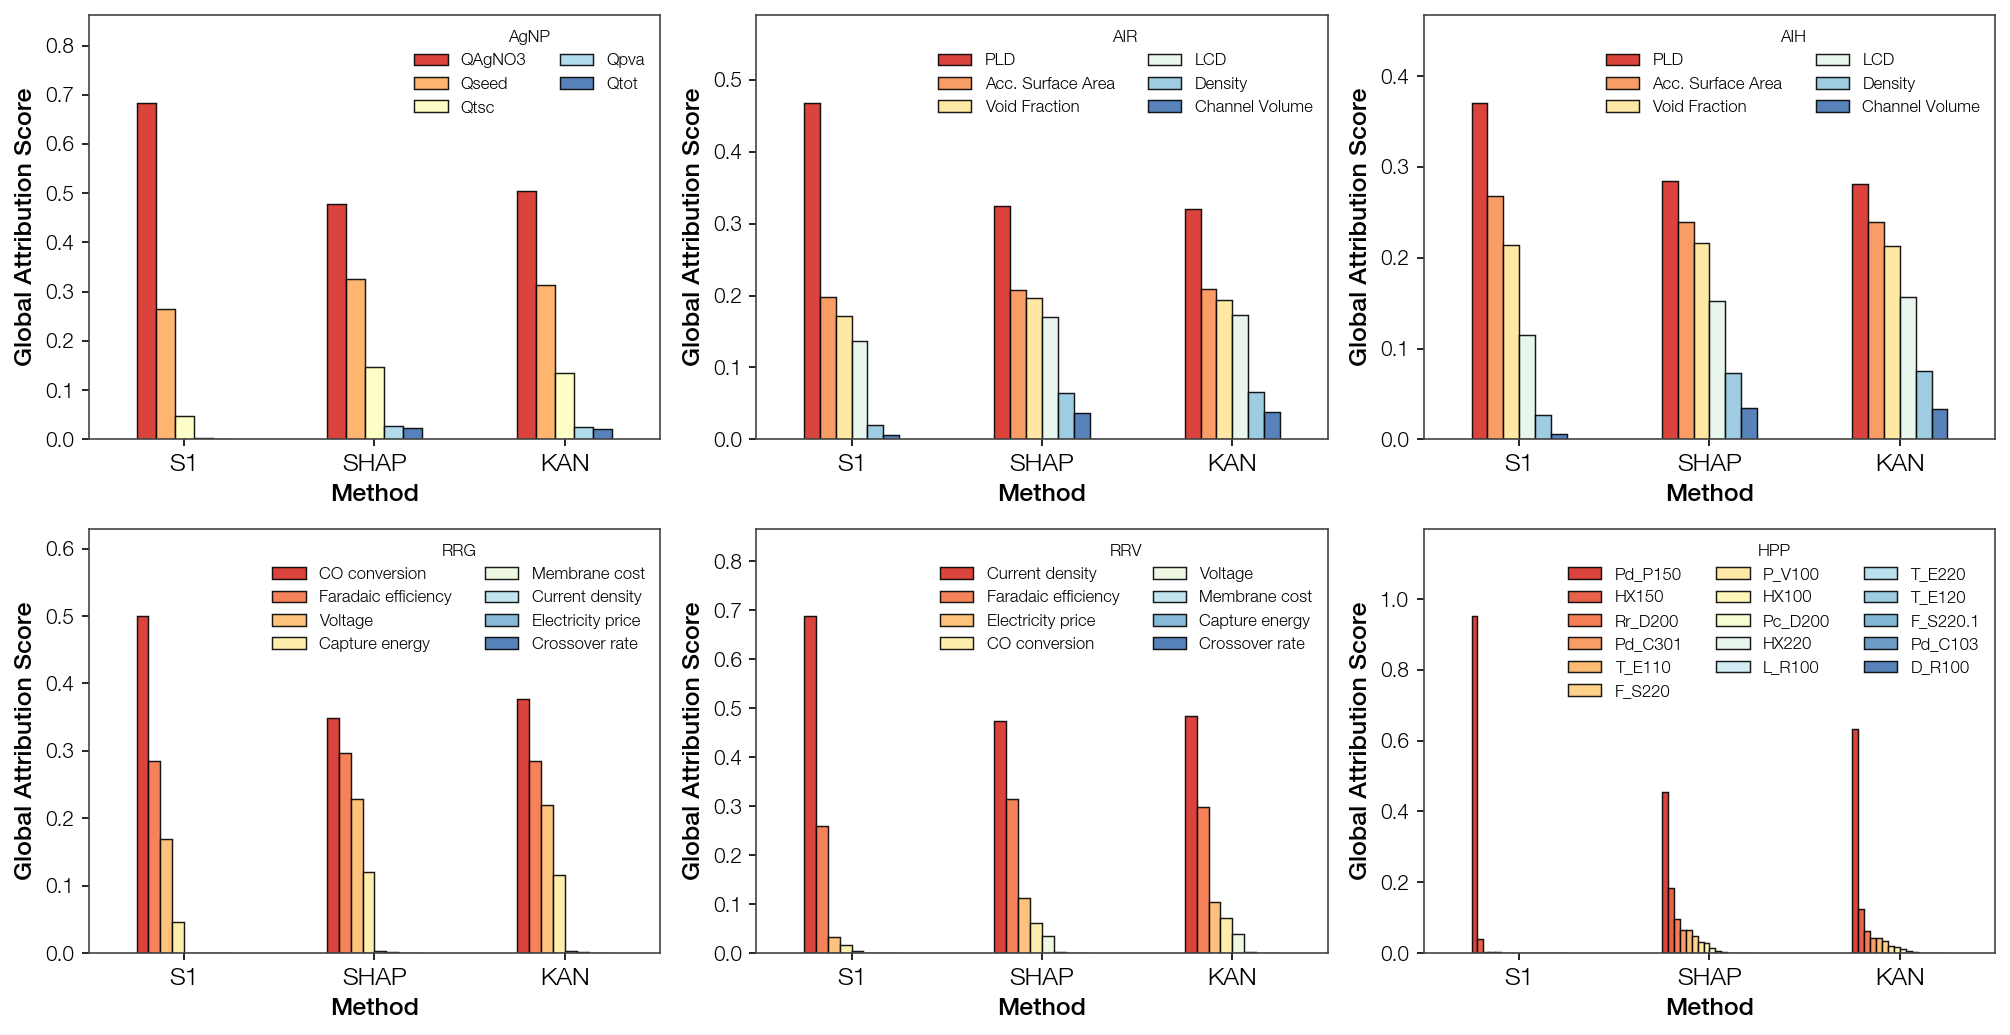


=== Combined metrics across 6 datasets (eps=0.001) ===
  Dataset  n_features  n_dropped  n_layers  num_params    R2     top_feature  top_feat_S1  top_feat_SHAP  top_feat_KAN  rho_KAN_vs_S1  rho_KAN_vs_SHAP
     AgNP           5          0         1          70 0.812          QAgNO3        0.684          0.477         0.505          1.000            1.000
CO2AR4500           6          0         1          54 0.762             PLD        0.468          0.325         0.321          1.000            1.000
CO2AH4500           6          0         1          54 0.761             PLD        0.371          0.285         0.281          1.000            1.000
 CO2RRLCA           8          2         1          72 0.965   CO conversion        0.500          0.349         0.376          1.000            1.000
 CO2RRNPV           8          2         1         112 0.971 Current density        0.688          0.473         0.483          1.000            1.000
 CO2HPx10          16          5      

In [25]:
data_list = [
    # 'CrossedBarrel',
    'AgNP',
    # 'P3HT',
    'CO2AR4500',
    'CO2AH4500',
    'CO2RRLCA',
    'CO2RRNPV',
    # 'CO2RRMSP',
    'CO2HPx10',
]
title_map = {
    "CrossedBarrel": "CBR",
    "CO2AR4500": "AIR",
    "CO2AH4500": "AIH",
    "CO2RRNPV": "RRV",
    "CO2RRMSP": "RRP",
    "CO2RRLCA": "RRG",
    "CO2HPx10": "HPP",
}
df_metrics = analyze_dataset_list(data_list, eps=0.001, title_map=title_map,
                                  combined_name='VS_conventionals_All')

In [28]:
df_metrics_combined = pd.concat([df_metrics_analytic, df_metrics], ignore_index=True)
print("\n=== All datasets combined ===")
print(df_metrics_combined.to_string(index=False, float_format='{:.3f}'.format))

csv_path = os.path.join(dir_paper_figure, "VS_conventionals_combined_metrics.csv")
df_metrics_combined.to_csv(csv_path, index=False)
print(f"\nSaved to: {csv_path}")


=== All datasets combined ===
    Dataset  n_features  n_dropped  n_layers  num_params    R2     top_feature  top_feat_S1  top_feat_SHAP  top_feat_KAN  rho_KAN_vs_S1  rho_KAN_vs_SHAP
exponential           2          0         1          28 1.000        Exponent        0.914          0.751         0.766          1.000            1.000
  logarithm           2          0         1          28 1.000             Log        0.524          0.499         0.512          1.000           -1.000
       log2           2          0         2          28 1.000          Linear        0.514          0.513         0.491         -1.000           -1.000
 rosenbrock           2          0         2          28 0.911       Quadratic        0.681          0.541         0.706          1.000            1.000
       AgNP           5          0         1          70 0.812          QAgNO3        0.684          0.477         0.505          1.000            1.000
  CO2AR4500           6          0         1       